In [29]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [30]:
# ============================================================
# LOAD THE KAGGLE ONLINE RETAIL DATASET
# ============================================================

df = pd.read_csv("/content/drive/MyDrive/MachineLearningModels/Unsupervised Learning/data.csv", encoding='latin1')
df.head()

display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [31]:
# ============================================================
# UNDERSTAND THE DATASET
# ============================================================

print("Rows and columns:", df.shape)

df.info()

display(df.describe())

Rows and columns: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [32]:

# ============================================================
# CHECK MISSING VALUES
# ============================================================

missing_values = df.isnull().sum()

display(missing_values)

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [33]:

# ============================================================
# CONVERT INVOICEDATE TO DATETIME
# ============================================================

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)
#errors="coerce"         # invalid dates become NaT


In [34]:
# ============================================================
# REMOVE MISSING CUSTOMER INFORMATION
# ============================================================

df = df.dropna(
    subset=[
        "CustomerID",
        "InvoiceDate",
        "Quantity",
        "UnitPrice"
    ]
)

In [35]:
# ============================================================
# REMOVE CANCELLED INVOICES
# ============================================================
#means:Give me the rows where InvoiceNo does NOT start with C.

df = df[
    ~df["InvoiceNo"].astype(str).str.startswith("C")
]

In [36]:
# ============================================================
# KEEP ONLY VALID SALES
# ============================================================

df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()


In [37]:
# ============================================================
# CALCULATE TOTAL SALES
# ============================================================

df["Sales"] = (
    df["Quantity"] *
    df["UnitPrice"]
)

display(
    df[
        [
            "InvoiceNo",
            "CustomerID",
            "Quantity",
            "UnitPrice",
            "Sales"
        ]
    ].head()
)

,InvoiceNo,CustomerID,Quantity,UnitPrice,Sales
0,536365,17850.0,6,2.55,15.30
1,536365,17850.0,6,3.39,20.34
2,536365,17850.0,8,2.75,22.00
3,536365,17850.0,6,3.39,20.34
4,536365,17850.0,6,3.39,20.34


In [38]:
# ============================================================
# CREATE SNAPSHOT DATE FOR RECENCY
# ============================================================

snapshot_date = (
    df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

print("Snapshot date:", snapshot_date)

Snapshot date: 2011-12-10 12:50:00


In [39]:
# ============================================================
# CREATE RFM ANALYSIS
# ============================================================

rfm = df.groupby("CustomerID").agg(

    # Number of days since the customer's last purchase
    Recency=(
        "InvoiceDate",
        lambda x: (snapshot_date - x.max()).days
    ),

    # Number of unique orders made by the customer
    Frequency=(
        "InvoiceNo",
        "nunique"
    ),

    # Total amount spent by the customer
    Monetary=(
        "Sales",
        "sum"
    )

).reset_index()


# Display the RFM table
display(rfm.head())


# ============================================================
# CHECK RFM DATA
# ============================================================

print("Number of customers:", len(rfm))

display(rfm.describe())


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


Number of customers: 4338


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


In [40]:

# ============================================================
# SELECT RFM FEATURES FOR PCA
# ============================================================

X = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

display(X.head())


# ============================================================
# LOG TRANSFORM THE RFM DATA
# ============================================================

# log1p helps reduce the effect of very large values
X_log = np.log1p(X)

display(X_log.head())

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [41]:
# ============================================================
# STANDARDIZE THE DATA
# ============================================================

# PCA works better when the features are on a similar scale

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)


# ============================================================
# PERFORM PCA
# ============================================================

# Reduce 3 RFM features into 2 principal components

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X_scaled)


# ============================================================
# ADD PC1 AND PC2 TO THE RFM DATA
# ============================================================

rfm["PC1"] = X_pca[:, 0]

rfm["PC2"] = X_pca[:, 1]

display(rfm.head())


,CustomerID,Recency,Frequency,Monetary,PC1,PC2
0,12346.0,326,1,77183.60,0.872658,2.686758
1,12347.0,2,7,4310.00,2.550260,-0.804427
2,12348.0,75,4,1797.24,0.475142,0.746121
3,12349.0,19,1,1757.55,0.145832,-0.460480
4,12350.0,310,1,334.40,-1.688990,0.676555


In [42]:
# ============================================================
# CHECK PCA EXPLAINED VARIANCE
# ============================================================

print(
    "PC1 explains:",
    round(
        pca.explained_variance_ratio_[0] * 100,
        2
    ),
    "%"
)

print(
    "PC2 explains:",
    round(
        pca.explained_variance_ratio_[1] * 100,
        2
    ),
    "%"
)


# Calculate total variance explained by PC1 and PC2

total_variance = (
    pca.explained_variance_ratio_.sum()
    * 100
)

print(
    "Total variance explained:",
    round(total_variance, 2),
    "%"
)


PC1 explains: 75.1 %
PC2 explains: 18.76 %
Total variance explained: 93.86 %


In [43]:
# ============================================================
# PCA LOADINGS
# ============================================================

# Loadings show how each RFM feature contributes
# to PC1 and PC2

loadings = pd.DataFrame(
    pca.components_,
    columns=[
        "Recency",
        "Frequency",
        "Monetary"
    ],
    index=[
        "PC1",
        "PC2"
    ]
)

display(loadings)


,Recency,Frequency,Monetary
PC1,-0.512079,0.617843,0.596695
PC2,0.849645,0.262445,0.457413


In [44]:
 #============================================================
# PREPARE ELBOW AND SILHOUETTE METHODS
# ============================================================

# We will test different numbers of clusters

k_values = range(2, 9)

inertias = []

silhouette_scores = []

In [45]:
# ============================================================
# TEST DIFFERENT K VALUES
# ============================================================

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)
 # Store inertia for the Elbow Method
    inertias.append(
        kmeans.inertia_
    )

    # Store silhouette score
    silhouette_scores.append(
        silhouette_score(
            X_scaled,
            labels
        )
    )


# ============================================================
# CREATE EVALUATION TABLE
# ============================================================

evaluation_df = pd.DataFrame({

    "K": list(k_values),

    "Inertia": inertias,

    "Silhouette Score": silhouette_scores

})

display(evaluation_df)

,K,Inertia,Silhouette Score
0,2,6481.225323,0.432940
1,3,4867.846645,0.336510
2,4,3938.509954,0.337134
3,5,3295.976329,0.316097
4,6,2855.011247,0.313329
5,7,2548.914324,0.309975
6,8,2336.777508,0.300782


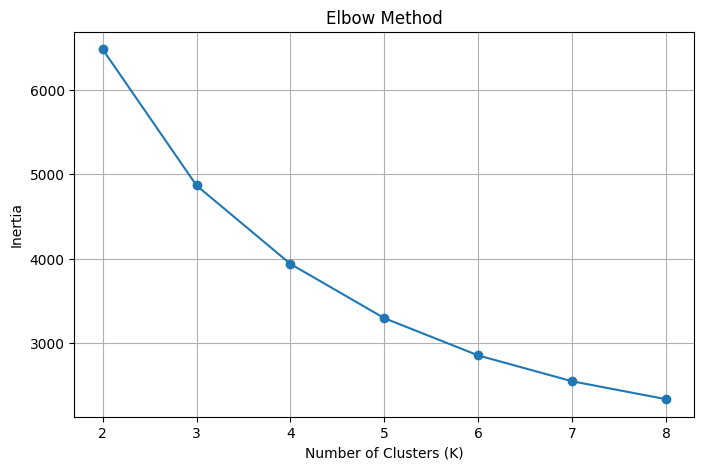

In [46]:

# ============================================================
# ELBOW METHOD GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Inertia"
)

plt.title(
    "Elbow Method"
)

plt.xticks(
    list(k_values)
)

plt.grid(True)

plt.show()

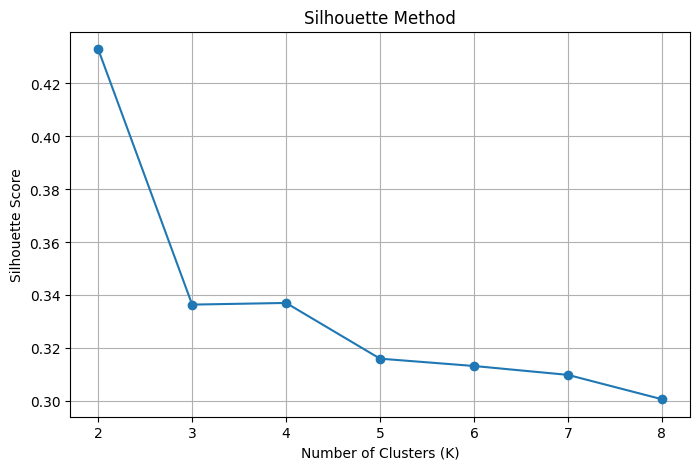

In [47]:
# ============================================================
# SILHOUETTE METHOD GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Silhouette Method"
)

plt.xticks(
    list(k_values)
)

plt.grid(True)

plt.show()


In [48]:
# ============================================================
# FIND THE BEST K USING SILHOUETTE SCORE
# ============================================================

best_k = evaluation_df.loc[
    evaluation_df["Silhouette Score"].idxmax(),
    "K"
]

print(
    "Best K based on silhouette score:",
    best_k
)


Best K based on silhouette score: 2


In [49]:
# ============================================================
# PERFORM FINAL KMEANS CLUSTERING
# ============================================================

kmeans = KMeans(
    n_clusters=int(best_k),
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(
    X_scaled
)


# Display customers with their clusters

display(rfm.head())


# ============================================================
# COUNT CUSTOMERS IN EACH CLUSTER
# ============================================================

cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

display(cluster_counts)

,CustomerID,Recency,Frequency,Monetary,PC1,PC2,Cluster
0,12346.0,326,1,77183.60,0.872658,2.686758,1
1,12347.0,2,7,4310.00,2.550260,-0.804427,1
2,12348.0,75,4,1797.24,0.475142,0.746121,1
3,12349.0,19,1,1757.55,0.145832,-0.460480,0
4,12350.0,310,1,334.40,-1.688990,0.676555,0


,count
Cluster,
0,2671
1,1667


In [50]:
# ============================================================
# CREATE CLUSTER PROFILE
# ============================================================

cluster_profile = rfm.groupby("Cluster").agg(

    # Number of customers in each cluster
    Customers=(
        "CustomerID",
        "count"
    ),

    # Average number of days since last purchase
    Average_Recency=(
        "Recency",
        "mean"
    ),

    # Average number of orders
    Average_Frequency=(
        "Frequency",
        "mean"
    ),

    # Average amount spent
    Average_Monetary=(
        "Monetary",
        "mean"
    ),

    # Total amount spent by the cluster
    Total_Monetary=(
        "Monetary",
        "sum"
    )

).reset_index()


# Round the numbers

cluster_profile = cluster_profile.round(2)

display(cluster_profile)

,Cluster,Customers,Average_Recency,Average_Frequency,Average_Monetary,Total_Monetary
0,0,2671,134.14,1.67,497.74,1329461.12
1,1,1667,25.88,8.44,4548.26,7581946.78


In [51]:
# ============================================================
# FIND THE HIGH-VALUE CLUSTER
# ============================================================

# We identify the cluster based on actual spending,
# not the cluster number.

high_value_cluster = cluster_profile.loc[
    cluster_profile["Average_Monetary"].idxmax(),
    "Cluster"
]

print(
    "High-value cluster:",
    high_value_cluster
)

High-value cluster: 1


In [52]:
# ============================================================
# PRINT CUSTOMERS FROM CLUSTER 0
# ============================================================

cluster_0_customers = rfm[rfm["Cluster"] == 0]

print("Customers in Cluster 0:")
display(cluster_0_customers)



Customers in Cluster 0:


,CustomerID,Recency,Frequency,Monetary,PC1,PC2,Cluster
3,12349.0,19,1,1757.55,0.145832,-0.460480,0
4,12350.0,310,1,334.40,-1.688990,0.676555,0
6,12353.0,204,1,89.00,-2.153987,-0.066231,0
7,12354.0,232,1,1079.40,-1.023559,0.919003,0
8,12355.0,214,1,459.40,-1.397610,0.557738,0
...,...,...,...,...,...,...,...
4331,18277.0,58,1,110.38,-1.576928,-0.778344,0
4332,18278.0,74,1,173.90,-1.454476,-0.462056,0
4333,18280.0,278,1,180.60,-1.938635,0.384536,0
4334,18281.0,181,1,80.82,-2.153731,-0.176343,0


In [53]:
# ============================================================
# FILTER THE HIGH-VALUE CLUSTER
# ============================================================

high_value_customers = rfm[
    rfm["Cluster"] == high_value_cluster
].copy()


# Sort customers from highest to lowest spending

high_value_customers = high_value_customers.sort_values(
    "Monetary",
    ascending=False
)


# Display the filtered customers

display(
    high_value_customers.head(20)
)

,CustomerID,Recency,Frequency,Monetary,PC1,PC2,Cluster
1689,14646.0,2,73,280206.02,6.543461,1.568855,1
4201,18102.0,1,60,259657.30,6.487500,1.209848,1
3728,17450.0,8,46,194550.79,5.539937,1.958263,1
3008,16446.0,1,2,168472.50,3.557427,-0.104942,1
1879,14911.0,1,201,143825.06,7.290288,1.455034,1
55,12415.0,24,21,124914.53,4.252635,2.153154,1
1333,14156.0,10,55,117379.63,5.381970,1.969008,1
3771,17511.0,3,31,91062.38,5.141842,1.020266,1
2702,16029.0,39,63,81024.84,4.833561,2.703985,1
0,12346.0,326,1,77183.60,0.872658,2.686758,1


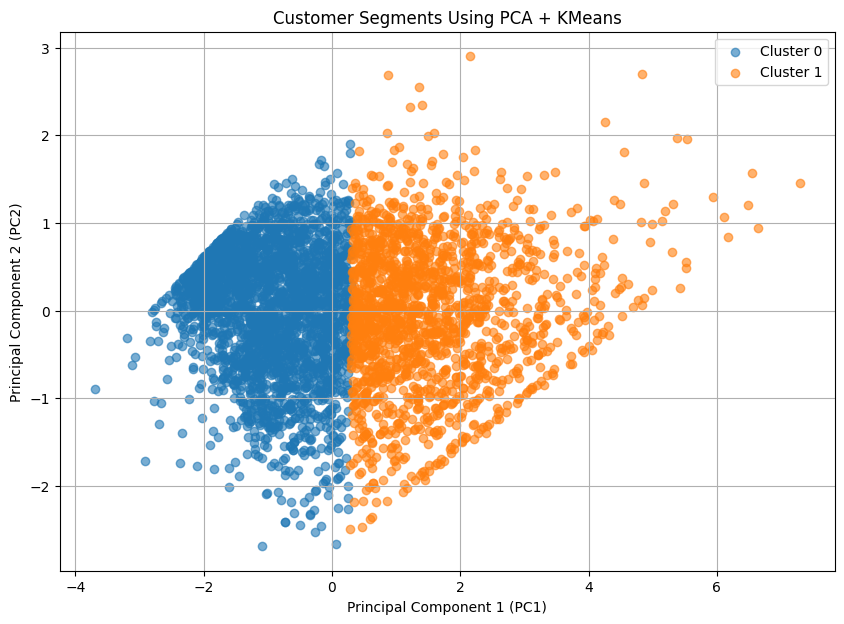

In [54]:
# ============================================================
# PCA GRAPH WITH KMEANS CLUSTERS
# ============================================================

plt.figure(figsize=(10, 7))

for cluster in sorted(
    rfm["Cluster"].unique()
):

    cluster_data = rfm[
        rfm["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )


plt.xlabel(
    "Principal Component 1 (PC1)"
)

plt.ylabel(
    "Principal Component 2 (PC2)"
)

plt.title(
    "Customer Segments Using PCA + KMeans"
)

plt.legend()

plt.grid(True)

plt.show()

In [55]:
# ============================================================
# 3D CUSTOMER CLUSTER VISUALIZATION
# ============================================================

import plotly.express as px

# Create a text version of Cluster for the legend
# This keeps the original Cluster column numeric
rfm["Cluster_Label"] = rfm["Cluster"].astype(str)

# Create the 3D graph
fig = px.scatter_3d(
    rfm,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color="Cluster_Label",

    # Information shown when you hover over a customer
    hover_data=[
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "Cluster"
    ],

    title="3D Customer Segmentation Using RFM"
)

# Label the axes
fig.update_layout(
    scene=dict(
        xaxis_title="Recency (Days)",
        yaxis_title="Frequency (Number of Orders)",
        zaxis_title="Monetary (Total Spending)"
    ),
    legend_title="Customer Cluster"
)

# Show interactive graph
fig.show()

In [56]:
# ============================================================
# EXPORT RESULTS TO EXCEL
# ============================================================

output_file = (
    "/content/drive/MyDrive/MachineLearningModels/Unsupervised Learning/"
    "customer_segmentation_PCA_KMeans.xlsx"
)


with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    # Complete customer RFM + PCA + cluster data
    rfm.to_excel(
        writer,
        sheet_name="RFM_Clusters",
        index=False
    )

    # Summary of each cluster
    cluster_profile.to_excel(
        writer,
        sheet_name="Cluster_Profile",
        index=False
    )

    # Elbow and silhouette results
    evaluation_df.to_excel(
        writer,
        sheet_name="Elbow_Silhouette",
        index=False
    )

    # PCA loadings
    loadings.to_excel(
        writer,
        sheet_name="PCA_Loadings"
    )

    # Filtered high-value customers
    high_value_customers.to_excel(
        writer,
        sheet_name="Filtered_Cluster",
        index=False
    )

    # Filtered high-value customers
    cluster_0_customers.to_excel(
        writer,
        sheet_name="Zero_Cluster_customers",
        index=False
    )

# ============================================================
# FINAL MESSAGE
# ============================================================

print(
    "PCA, KMeans, clustering evaluation, "
    "filtering, and Excel export completed!"
)

print(
    "Best K:",
    best_k
)

print(
    "High-value cluster:",
    high_value_cluster
)
print(
    "zero-cluster-customerr:",
    cluster_0_customers
)
print(
    "Excel file saved to:"
)

print(output_file)

# ============================================================
# AUTOMATICALLY ADJUST ALL COLUMN WIDTHS
# ============================================================

from openpyxl import load_workbook

# Open the Excel file
wb = load_workbook(output_file)

# Go through every sheet
for ws in wb.worksheets:

    # Go through every column
    for column in ws.columns:

        max_length = 0

        for cell in column:
            if cell.value is not None:
                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

        # Add 3 extra spaces
        ws.column_dimensions[
            column[0].column_letter
        ].width = max_length + 3


# Save the updated Excel file
wb.save(output_file)

print("Excel file saved with adjusted column widths!")
print(output_file)

PCA, KMeans, clustering evaluation, filtering, and Excel export completed!
Best K: 2
High-value cluster: 1
zero-cluster-customerr:       CustomerID  Recency  Frequency  Monetary       PC1       PC2  Cluster
3        12349.0       19          1   1757.55  0.145832 -0.460480        0
4        12350.0      310          1    334.40 -1.688990  0.676555        0
6        12353.0      204          1     89.00 -2.153987 -0.066231        0
7        12354.0      232          1   1079.40 -1.023559  0.919003        0
8        12355.0      214          1    459.40 -1.397610  0.557738        0
...          ...      ...        ...       ...       ...       ...      ...
4331     18277.0       58          1    110.38 -1.576928 -0.778344        0
4332     18278.0       74          1    173.90 -1.454476 -0.462056        0
4333     18280.0      278          1    180.60 -1.938635  0.384536        0
4334     18281.0      181          1     80.82 -2.153731 -0.176343        0
4335     18282.0        8        